In [ ]:
# ===================== ALL-IN-ONE: 3D simplex (tetrahedra) for Multiwell Function =====================
# Requirements: pyomo, ipopt (NLP), numpy, scipy, plotly, tqdm
# -----------------------------------------------------------------------------------------

import numpy as np
import itertools as it
from tqdm import tqdm
import pyomo.environ as pyo
from pyomo.opt import SolverStatus, TerminationCondition
from scipy.spatial import Delaunay
import plotly.graph_objects as go
import matplotlib.pyplot as plt


# ------------------------- Config knobs -------------------------
MIN_DIST   = 1e-8     # 去重阈值
ACTIVE_TOL = 1e-8     # active 判定容差
MS_AGG     = "sum"    # 单形 ms 聚合：'sum' 或 'mean'

# ------------------------- Multiwell function (2~3 minima) -------------------------
# 你可以调这些参数让极小点更分明/更多或更少
MW_PARAMS_1 = {
    "beta": 0.18,
    "c":    np.array([5.0, 5.0, 5.0], dtype=float),
    # wells: each is (mu (3,), a, sigma)
    "wells": [
        (np.array([3.0, 4.0, 6.0]), 3.2, 1.2),
        (np.array([7.0, 6.0, 4.0]), 3.0, 1.3),
        # 第三个井：想要 2 个极小点就注释掉这一行
        (np.array([6.5, 3.2, 7.5]), 2.6, 1.1),
    ]
}
MW_PARAMS = {
    "beta": 0.18,
    "c": np.array([5.0, 5.0, 5.0]),
    "wells": [
        (np.array([3.5, 4.0, 6.5]), 3.00, 1.10),
        (np.array([6.5, 6.0, 3.5]), 3.00+1e-4, 1.10),
    ]
}


def f_multiwell_numpy(xyz, params=MW_PARAMS):
    x = np.asarray(xyz, dtype=float)
    beta = params["beta"]; c = params["c"]; wells = params["wells"]
    base = beta * np.sum((x - c)**2)
    dips = 0.0
    for mu, a, sig in wells:
        r2 = float(np.sum((x - mu)**2))
        dips += a * np.exp(- r2 / (2.0 * sig**2))
    return base - dips

# ------------------------- Build the Pyomo model of f(x,y,z) -------------------------
def build_multiwell_model(bounds_xyz=(0.0, 10.0), params=MW_PARAMS):
    """ 单场景模型：只有 x,y,z 三个变量和一个光滑目标 obj_expr=f(x,y,z) """
    lo, hi = bounds_xyz
    m = pyo.ConcreteModel()
    m.x = pyo.Var(bounds=(lo, hi))
    m.y = pyo.Var(bounds=(lo, hi))
    m.z = pyo.Var(bounds=(lo, hi))

    beta = params["beta"]
    cx, cy, cz = params["c"].tolist()

    # 构造 f(x,y,z) 的表达式
    # base bowl
    base = beta*((m.x - cx)**2 + (m.y - cy)**2 + (m.z - cz)**2)

    # sum of Gaussian wells
    dips = 0
    for (mu, a, sig) in params["wells"]:
        mx, my, mz = mu.tolist()
        r2 = (m.x - mx)**2 + (m.y - my)**2 + (m.z - mz)**2
        # 用 Pyomo 的 exp
        dips += a * pyo.exp(- r2 / (2.0 * (sig**2)))

    m.obj_expr = pyo.Expression(expr = base - dips)
    return m, [m.x, m.y, m.z]

def build_models(num_scenarios=1, bounds_xyz=(0.0,10.0), params=MW_PARAMS):
    """ 生成 num_scenarios 个“场景”副本（参数相同），以便沿用原有多场景接口/打印 """
    model_list, first_stg_vars_list = [], []
    for _ in range(num_scenarios):
        m, vars3 = build_multiwell_model(bounds_xyz=bounds_xyz, params=params)
        model_list.append(m)
        first_stg_vars_list.append(vars3)
    m_tmpl_list = [model_list[0], first_stg_vars_list[0]]
    T = None  # 保留接口占位
    return model_list, first_stg_vars_list, m_tmpl_list, T

# ------------------------- Basic utils -------------------------
def corners_from_var_bounds(vars_3):
    bnds = []
    for v in vars_3:
        lb, ub = v.lb, v.ub
        if lb is None or ub is None:
            raise ValueError(f"{v.name} 缺少上下界")
        bnds.append((float(lb), float(ub)))
    return [tuple(p) for p in it.product(*[(lo, hi) for (lo,hi) in bnds])]

def too_close(p, nodes, tol=MIN_DIST):
    return any(np.linalg.norm(np.asarray(p)-np.asarray(q)) < tol for q in nodes)

def evaluate_Q_at(model, first_stg_vars, first_stg_vals, solver):
    """
    把 x,y,z 固定到给定值，直接数值计算 obj_expr；不调用 solver。
    这样就不会出现“模型没有自由变量”的 NL 接口报错。
    """
    # 固定变量
    for u, v in zip(first_stg_vars, first_stg_vals):
        u.fix(float(v))

    try:
        # 直接对 Pyomo 表达式求值
        val = float(pyo.value(model.obj_expr))
        return val
    finally:
        # 清理：解锁变量
        for u in first_stg_vars:
            if u.fixed:
                u.unfix()


# ------------------------- Single tetra & scene: ms solve -------------------------
def ms_on_tetra_for_scene(model_tmpl, first_vars, solver, tet_vertices, fverts_scene):
    """
    在一个四面体上：
      ms = min_{lambda>=0, 1^T lambda=1} [ obj_expr(x(lambda)) - sum_j lambda_j f(v_j) ]
    x(lambda)=∑ λ_j * v_j， 这里一个“场景”就是一个相同的 f
    """
    m = model_tmpl.clone()

    # 取 x,y,z
    vx = m.find_component(first_vars[0].name)
    vy = m.find_component(first_vars[1].name)
    vz = m.find_component(first_vars[2].name)
    if any(v is None for v in (vx,vy,vz)):
        raise RuntimeError("克隆模型中找不到 x/y/z")

    # 重心变量
    m.lam = pyo.Var(range(4), domain=pyo.NonNegativeReals)
    m.lam_sum = pyo.Constraint(expr=sum(m.lam[j] for j in range(4)) == 1.0)

    tx = [float(tet_vertices[j][0]) for j in range(4)]
    ty = [float(tet_vertices[j][1]) for j in range(4)]
    tz = [float(tet_vertices[j][2]) for j in range(4)]
    m.link_x = pyo.Constraint(expr=vx == sum(m.lam[j]*tx[j] for j in range(4)))
    m.link_y = pyo.Constraint(expr=vy == sum(m.lam[j]*ty[j] for j in range(4)))
    m.link_z = pyo.Constraint(expr=vz == sum(m.lam[j]*tz[j] for j in range(4)))

    # As
    m.As = pyo.Var()
    m.As_def = pyo.Constraint(expr=m.As == sum(m.lam[j]*float(fverts_scene[j]) for j in range(4)))

    if hasattr(m, 'obj'): m.del_component('obj')
    m.obj = pyo.Objective(expr=m.obj_expr - m.As, sense=pyo.minimize)

    res = solver.solve(m, tee=False)
    ok = (res.solver.status == SolverStatus.ok) and \
         (res.solver.termination_condition in (TerminationCondition.optimal,
                                               TerminationCondition.locallyOptimal))
    if not ok:
        return float('inf'), None, None

    ms_val = float(pyo.value(m.obj))
    lam_star = np.array([pyo.value(m.lam[j]) for j in range(4)], dtype=float)
    new_pt = np.dot(lam_star, np.array(tet_vertices, dtype=float))
    return ms_val, lam_star, tuple(map(float, new_pt))

# ------------------------- Evaluate all tetrahedra -------------------------
def evaluate_all_tetra(nodes, scen_values, model_list, first_vars_list, solver):
    """
    nodes           : 当前节点列表（3D 点）
    scen_values     : 形状 S×len(nodes)，每个“场景”在每个节点上的真实值
    返回 tri, per_tet； per_tet 每项含：
      'simplex_index','vert_idx','verts','fverts_sum','ms_per_scene','ms','LB','UB','x_ms_best_scene','best_scene'
    """
    pts = np.asarray(nodes, dtype=float)
    if len(pts) < 4:
        return None, []
    tri = Delaunay(pts)  # simplices: (M,4)
    S = len(model_list)

    per_tet = []
    for k, simp in enumerate(tri.simplices):
        idxs = list(map(int, simp))
        verts = [tuple(pts[i]) for i in idxs]
        # 各场景四顶点值（这里各场景相同）
        fverts_per_scene = [[scen_values[ω][i] for i in idxs] for ω in range(S)]
        # “总 f” 顶点
        fverts_sum = [sum(fverts_per_scene[ω][j] for ω in range(S)) for j in range(4)]

        ms_scene = []
        xms_scene = []
        for ω in range(S):
            ms_val, lam_star, new_pt = ms_on_tetra_for_scene(
                model_list[ω], first_vars_list[ω], solver, verts, fverts_per_scene[ω]
            )
            ms_scene.append(ms_val)
            xms_scene.append(new_pt)

        if MS_AGG == "sum":
            ms_total = float(np.sum(ms_scene))
        elif MS_AGG == "mean":
            ms_total = float(np.mean(ms_scene))
        else:
            raise ValueError("MS_AGG must be 'sum' or 'mean'")

        LB = float(np.min(fverts_sum) + ms_total)
        UB = float(np.max(fverts_sum) + ms_total)

        best_scene = int(np.argmin(ms_scene))
        x_ms_best = xms_scene[best_scene]

        per_tet.append({
            "simplex_index": k,
            "vert_idx": idxs,
            "verts": verts,
            "fverts_sum": fverts_sum,
            "ms_per_scene": ms_scene,
            "ms": ms_total,
            "LB": LB,
            "UB": UB,
            "x_ms_best_scene": x_ms_best,
            "best_scene": best_scene,
        })

    return tri, per_tet

# ------------------------- Pretty print (保留你原来的风格/颜色) -------------------------
def print_tetra_table(per_tet, active_mask, purple_set=None, prec=6):
    purple_set = set() if purple_set is None else set(purple_set)
    per_tet = sorted(per_tet, key=lambda r: r["simplex_index"])
    tet_ids = [r["simplex_index"] for r in per_tet]
    active_set = {tid for tid in tet_ids if active_mask.get(tid, False)}

    def _mark(tid):
        s = f"T{tid}"
        flags = []
        if tid in active_set:  flags.append("*")
        if tid in purple_set:  flags.append("^")
        return s + ("".join(flags) if flags else "")

    header = ["row\\simp"] + [_mark(tid) for tid in tet_ids]
    rows = [
        ["UB"] + [f"{r['UB']:.{prec}f}" for r in per_tet],
        ["LB"] + [f"{r['LB']:.{prec}f}" for r in per_tet],
        ["ms"] + [f"{r['ms']:.3e}"       for r in per_tet],
    ]

    table = [header] + rows
    colw = [max(len(str(row[c])) for row in table) + 2 for c in range(len(header))]

    RED, PURPLE, RESET = "\033[31m", "\033[35m", "\033[0m"
    def colorize(col_idx, s):
        if col_idx == 0:
            return s
        tid = tet_ids[col_idx-1]
        if tid in purple_set:
            return f"{PURPLE}{s}{RESET}"
        elif tid in active_set:
            return f"{RED}{s}{RESET}"
        return s

    print("\n== Per-tetra summary ==")
    print("".join(colorize(c, str(header[c]).ljust(colw[c])) for c in range(len(header))))
    print("-"*sum(colw))
    for r in rows:
        line = []
        for c in range(len(header)):
            cell = str(r[c])
            pad  = cell.ljust(colw[c]) if c==0 else cell.rjust(colw[c])
            line.append(colorize(c, pad))
        print("".join(line))
    print("(红色列=active；紫色列=包含当前最小节点的单形；第1行=UB，第2行=LB，第3行=ms)\n")

def print_per_scenario_ms(per_tet, max_scenarios_to_print=10, prec=3):
    per_tet = sorted(per_tet, key=lambda r: r["simplex_index"])
    if not per_tet or "ms_per_scene" not in per_tet[0]:
        return
    S = len(per_tet[0]["ms_per_scene"])
    show = min(S, max_scenarios_to_print)
    head = "simp | " + " ".join([f"s{j}".rjust(10) for j in range(show)])
    print("== Per-tetra per-scenario ms (showing first", show, "of", S, "scenes) ==")
    print(head)
    print("-"*len(head))
    for r in per_tet:
        arr = r["ms_per_scene"][:show]
        sline = " ".join([f"{v:.{prec}e}".rjust(10) for v in arr])
        print(f"{r['simplex_index']:>4d} | {sline}")
    if show < S:
        print(f"... ({S-show} scenes omitted)")
    print()

# ------------------------- Plotly visualization -------------------------
def plot_iteration_plotly(iter_id, nodes, tri, active_mask, ub_node, next_node, per_tet):
    fig = go.Figure()
    nodes = np.asarray(nodes, float)

    # ----------- 计算 active 节点集合 -----------
    active_nodes_idx = set()
    for r in per_tet:
        if active_mask.get(r["simplex_index"], False):
            active_nodes_idx.update(r["vert_idx"])
    inactive_nodes_idx = set(range(len(nodes))) - active_nodes_idx

    # ----------- 浅灰色点：非 active 节点 -----------
    if inactive_nodes_idx:
        pts = nodes[list(inactive_nodes_idx)]
        fig.add_trace(go.Scatter3d(
            x=pts[:,0], y=pts[:,1], z=pts[:,2],
            mode='markers',
            marker=dict(size=4, color='lightgray'),
            name='inactive nodes'
        ))

    # ----------- 黑色点：active 节点 -----------
    if active_nodes_idx:
        pts = nodes[list(active_nodes_idx)]
        fig.add_trace(go.Scatter3d(
            x=pts[:,0], y=pts[:,1], z=pts[:,2],
            mode='markers',
            marker=dict(size=4, color='black'),
            name='active nodes'
        ))

    # ----------- 红色点：真实极小点 -----------
    min_points = np.array([[3.5, 4.0, 6.5],
                           [6.5, 6.0, 3.5]])  # 你定义的两个极小点
    fig.add_trace(go.Scatter3d(
        x=min_points[:,0], y=min_points[:,1], z=min_points[:,2],
        mode='markers',
        marker=dict(size=7, color='red', symbol='diamond'),
        name='true minima'
    ))

    # ----------- 绿色点：当前最小 UB 节点 -----------
    if ub_node is not None:
        fig.add_trace(go.Scatter3d(
            x=[ub_node[0]], y=[ub_node[1]], z=[ub_node[2]],
            mode='markers',
            marker=dict(size=8, color='green', symbol='circle'),
            name='current min node'
        ))

    # ----------- 蓝色点：next node -----------
    if next_node is not None:
        fig.add_trace(go.Scatter3d(
            x=[next_node[0]], y=[next_node[1]], z=[next_node[2]],
            mode='markers',
            marker=dict(size=8, color='blue', symbol='circle'),
            name='next node'
        ))

    # active 单形：橙色半透明四面体 + 灰边
    if tri is not None:
        pts = tri.points
        legend_mesh_added = False
        legend_edge_added = False

        for r in per_tet:
            sid = r["simplex_index"]
            if not active_mask.get(sid, False):
                continue
            idxs = r["vert_idx"]
            verts = np.array([pts[i] for i in idxs], dtype=float)

            I = [0, 0, 0, 1]
            J = [1, 1, 2, 2]
            K = [2, 3, 3, 3]

            fig.add_trace(go.Mesh3d(
                x=verts[:, 0], y=verts[:, 1], z=verts[:, 2],
                i=I, j=J, k=K,
                color="#ff7043",
                opacity=0.35,
                showscale=False,
                name="active simplex",
                showlegend=(not legend_mesh_added)
            ))
            legend_mesh_added = True

            edges = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
            for (a, b) in edges:
                pa, pb = verts[a], verts[b]
                fig.add_trace(go.Scatter3d(
                    x=[pa[0], pb[0]],
                    y=[pa[1], pb[1]],
                    z=[pa[2], pb[2]],
                    mode='lines',
                    line=dict(width=2, color="gray"),
                    name="active edge",
                    showlegend=(not legend_edge_added)
                ))
            legend_edge_added = True

        # 质心 hover：展示每个单形的 LB/UB/ms
        cent_x, cent_y, cent_z, texts = [], [], [], []
        for r in per_tet:
            v = np.mean(np.asarray(r["verts"]), axis=0)
            ms_strs = [f"{val:.2e}" for val in r["ms_per_scene"][:8]]
            more = "" if len(r["ms_per_scene"]) <= 8 else f" (+{len(r['ms_per_scene'])-8} more)"
            txt = (f"simp={r['simplex_index']}<br>"
                   f"LB={r['LB']:.6f}<br>UB={r['UB']:.6f}<br>"
                   f"ms={r['ms']:.3e}<br>"
                   f"ms_per_scene: [{', '.join(ms_strs)}]")
            cent_x.append(v[0]); cent_y.append(v[1]); cent_z.append(v[2]); texts.append(txt)

        fig.add_trace(go.Scatter3d(
            x=cent_x, y=cent_y, z=cent_z,
            mode='markers',
            marker=dict(size=1, opacity=0.0),
            text=texts, hoverinfo="text",
            name="tetra info",
            showlegend=False
        ))

    fig.update_layout(
        title=f"Iteration {iter_id}",
        scene=dict(
            xaxis_title="x",
            yaxis_title="y",
            zaxis_title="z",
            aspectmode="cube"
        ),
        width=900,
        height=650,
        legend=dict(itemsizing="constant")
    )
    fig.show()

# ------------------------- Main iterative loop (保留打印&逻辑) -------------------------
def run_simplex_3d(model_list, first_vars_list, solver, target_nodes=30,
                   min_dist=MIN_DIST, active_tol=ACTIVE_TOL, verbose=True):
    S = len(model_list)
    # 角点初始化
    nodes = corners_from_var_bounds(first_vars_list[0])

    # 缓存 f_ω(node_i)
    scen_values = [[None]*len(nodes) for _ in range(S)]
    for i, node in enumerate(nodes):
        for ω in range(S):
            scen_values[ω][i] = evaluate_Q_at(model_list[ω], first_vars_list[ω], node, solver)

    LB_hist, UB_hist, ms_hist, node_count = [], [], [], []
    UB_node_hist, add_node_hist = [], []

    it = 0
    while len(nodes) < target_nodes:
        # 全局 UB 与 UB 节点
        f_sum_per_node = [sum(scen_values[ω][i] for ω in range(S)) for i in range(len(nodes))]
        ub_idx = int(np.argmin(f_sum_per_node))
        UB_global = float(f_sum_per_node[ub_idx])
        UB_node = tuple(nodes[ub_idx])

        # 四面体评估
        tri, per_tet = evaluate_all_tetra(nodes, scen_values, model_list, first_vars_list, solver)
        if tri is None or not per_tet:
            if verbose: print("Not enough nodes to make tetrahedra; stop.")
            break

        # active
        active_mask = { r["simplex_index"]: (r["LB"] <= UB_global + active_tol) for r in per_tet }
        active = [r for r in per_tet if active_mask[r["simplex_index"]]]

        # 全局 LB（沿用你此前的口径）
        ms_adj = [r["ms"] for r in per_tet if ub_idx in r["vert_idx"]]
        if ms_adj:
            LB_global = UB_global + float(np.max(ms_adj))
        else:
            LB_global = float(np.min([r["LB"] for r in per_tet]))

        # 本轮 ms 指标
        ms_iter = float(np.min([r["ms"] for r in per_tet]))

        LB_hist.append(LB_global); UB_hist.append(UB_global); ms_hist.append(ms_iter)
        node_count.append(len(nodes)); UB_node_hist.append(UB_node)

        # 打印表（保持原输出风格）
        simp_with_min = [r["simplex_index"] for r in per_tet if ub_idx in r["vert_idx"]]
        purple_set = set(simp_with_min)
        print(f"[Iter {it}] UB node {UB_node} is in simplices {sorted(simp_with_min)}")
        print_tetra_table(per_tet, active_mask, purple_set=purple_set)
        print_per_scenario_ms(per_tet, max_scenarios_to_print=10)
        print(f"[Global UB] = {UB_global:.6f}\n")

        # -------- 选新点：从 active 里按 ms 升序依次尝试，太近则用“次小 ms” --------
        candidates = active if len(active) > 0 else per_tet
        candidates_sorted = sorted(candidates, key=lambda r: r["ms"])

        new_node = None
        for cand in candidates_sorted:
            cand_pt = cand.get("x_ms_best_scene", None)
            if cand_pt is None:
                continue
            if not too_close(cand_pt, nodes, tol=min_dist):
                new_node = cand_pt
                if verbose:
                    print(f"Chosen node {tuple(map(float, cand_pt))} with ms={cand['ms']:.3e} (simp {cand['simplex_index']})")
                break
            else:
                if verbose:
                    print(f"Skip candidate {tuple(map(float, cand_pt))} (simp {cand['simplex_index']})"
                          f" because too close (< {min_dist:g}).")

        if new_node is None and len(active) > 0:
            if verbose:
                print("[fallback] All active candidates too close; try all simplices...")
            all_sorted = sorted(per_tet, key=lambda r: r["ms"])
            for cand in all_sorted:
                cand_pt = cand.get("x_ms_best_scene", None)
                if cand_pt is None:
                    continue
                if not too_close(cand_pt, nodes, tol=min_dist):
                    new_node = cand_pt
                    if verbose:
                        print(f"Chosen node {tuple(map(float, cand_pt))} with ms={cand['ms']:.3e} (simp {cand['simplex_index']}) [fallback-all]")
                    break
                else:
                    if verbose:
                        print(f"Skip (all) candidate {tuple(map(float, cand_pt))} (simp {cand['simplex_index']})"
                              f" because too close (< {min_dist:g}).")

        if new_node is None:
            if verbose: print("New node too close for all candidates (or infeasible ms); stop.")
            break

        # 可视化
        plot_iteration_plotly(it, nodes, tri, active_mask, UB_node, new_node, per_tet)

        # 真实评估并加入节点
        new_vals = []
        for ω in range(S):
            val = evaluate_Q_at(model_list[ω], first_vars_list[ω], new_node, solver)
            new_vals.append(val)
        nodes.append(tuple(map(float, new_node)))
        for ω in range(S):
            scen_values[ω].append(new_vals[ω])

        it += 1

    return {
        "nodes": np.array(nodes, float),
        "LB_hist": LB_hist,
        "UB_hist": UB_hist,
        "ms_hist": ms_hist,
        "node_count": node_count,
        "UB_node_hist": UB_node_hist,
        "added_nodes": nodes[4:]  # 从角点之后加入的
    }

# ===================== MAIN =====================
RUN_QUICK_TEST = True  # True: 先用小规模验证

if RUN_QUICK_TEST:
    num_scenarios = 1
    target_nodes  = 20
else:
    num_scenarios = 3  # 需要多场景打印就>1；这里各场景相同参数
    target_nodes  = 30

bounds_xyz = (0.0, 10.0)

# build models
model_list, first_stg_vars_list, m_tmpl_list, T = build_models(
    num_scenarios=num_scenarios, bounds_xyz=bounds_xyz, params=MW_PARAMS
)

# Solver: 目标含 exp，需 NLP 求解器（推荐 ipopt）
solver = pyo.SolverFactory('ipopt')
# 可选参数：solver.options.update({...})

# run
hist = run_simplex_3d(
    model_list=model_list,
    first_vars_list=first_stg_vars_list,
    solver=solver,
    target_nodes=target_nodes,
    min_dist=MIN_DIST,
    active_tol=ACTIVE_TOL,
    verbose=True
)

print("\n==== Done ====")
print(f"Total nodes: {len(hist['nodes'])}")
print(f"Best UB: {min(hist['UB_hist']) if hist['UB_hist'] else None}")
print(f"Last LB: {hist['LB_hist'][-1] if hist['LB_hist'] else None}")
# ===========================================================================================


[Iter 0] UB node (10.0, 10.0, 0.0) is in simplices [3, 4]

== Per-tetra summary ==
row\simp  T0*         T1*         T2*         T3*^        T4*^        T5*         
----------------------------------------------------------------------------------
UB           -0.631431   -2.138711   -0.631415   -2.138807   -2.138807   -2.138711
LB           -0.631431   -2.138711   -0.631415   -2.138807   -2.138807   -2.138711
ms          -1.413e+01  -1.564e+01  -1.413e+01  -1.564e+01  -1.564e+01  -1.564e+01
(红色列=active；紫色列=包含当前最小节点的单形；第1行=UB，第2行=LB，第3行=ms)

== Per-tetra per-scenario ms (showing first 1 of 1 scenes) ==
simp |         s0
-----------------
   0 | -1.413e+01
   1 | -1.564e+01
   2 | -1.413e+01
   3 | -1.564e+01
   4 | -1.564e+01
   5 | -1.564e+01

[Global UB] = 13.500000

Chosen node (6.3022301132267975, 5.868169576726585, 3.69772137141535) with ms=-1.564e+01 (simp 4)


[Iter 1] UB node (6.3022301132267975, 5.868169576726585, 3.69772137141535) is in simplices [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

== Per-tetra summary ==
row\simp  T0*^        T1*^        T2*^        T3*^        T4*^        T5*^        T6*^        T7*^        T8*^        T9*^        T10*^       T11*^       
----------------------------------------------------------------------------------------------------------------------------------------------------------
UB            4.494966    4.494963    4.494963    4.494966    4.499370    4.499371    4.495037    4.494962    4.499370    4.499370    4.494962    4.495037
LB          -11.143841  -11.143844  -11.143844  -11.143841  -11.139437  -11.139435  -11.143770  -11.143844  -11.139437  -11.139437  -11.143844  -11.143770
ms          -9.005e+00  -9.005e+00  -9.005e+00  -9.005e+00  -9.001e+00  -9.001e+00  -9.005e+00  -9.005e+00  -9.001e+00  -9.001e+00  -9.005e+00  -9.005e+00
(红色列=active；紫色列=包含当前最小节点的单形；第1行=UB，第2行=LB，第3行=ms)

== Per-tetra per-sc

WARNING (W1002): Setting Var 'x' to a numeric value `10.000000034984048`
outside the bounds (0.0, 10.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
[Iter 2] UB node (6.3022301132267975, 5.868169576726585, 3.69772137141535) is in simplices [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

== Per-tetra summary ==
row\simp  T0*^        T1*^        T2*^        T3*^        T4*^        T5*^        T6*^        T7*^        T8*^        T9*^        T10*^       T11*^       T12*^       T13*^       
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
UB            8.999990    8.999920    8.854961    8.927940    4.495037    5.821520    4.499370    4.499370    4.494966    4.494963    4.494963    4.495037    4.499370    4.499372
LB           -6.638817   -6.638886   -6.783846   -6.710867  -11.143770   -9.817286  -11.139437  -11.139437  -11.143841  -11.1

WARNING (W1002): Setting Var 'z' to a numeric value `-8.922241728935112e-09`
outside the bounds (0.0, 10.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
[Iter 3] UB node (6.3022301132267975, 5.868169576726585, 3.69772137141535) is in simplices [0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]

== Per-tetra summary ==
row\simp  T0*^        T1*^        T2*^        T3*^        T4          T5*^        T6*^        T7*^        T8*^        T9*^        T10*^       T11*^       T12*^       T13*^       T14*^       T15*^       T16*^       
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
UB           10.501523    8.854980    8.927948    8.999990    8.999920   10.141980    8.999990    8.854961    8.927940    4.495037    4.494963    4.499370    4.499370    5.821473    4.495037    4.499370    4.499372
LB  

WARNING (W1002): Setting Var 'x' to a numeric value `-2.5537213512501124e-09`
outside the bounds (0.0, 10.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
[Iter 4] UB node (6.3022301132267975, 5.868169576726585, 3.69772137141535) is in simplices [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19]

== Per-tetra summary ==
row\simp  T0          T1*^        T2*^        T3*^        T4*^        T5*^        T6*^        T7*^        T8*^        T9*^        T10*^       T11*^       T12         T13*^       T14*^       T15*^       T16*^       T17*^       T18*^       T19*^       
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
UB            8.999924   10.141980    8.999990    8.999990   10.489389    8.758483    8.854961   10.489389    8.248415    6.473935   10.40

...

[Iter 38] UB node (6.3022301132267975, 5.868169576726585, 3.69772137141535) is in simplices [47, 48, 49, 50, 51, 52, 61, 81, 86, 87, 89, 90, 116, 118, 122, 124, 126, 155, 156, 159, 164, 165, 166, 171, 173, 174, 176, 193, 194, 195]

== Per-tetra summary ==
row\simp  T0          T1          T2          T3          T4          T5          T6          T7          T8*         T9          T10         T11         T12         T13         T14         T15         T16         T17*        T18*        T19         T20*        T21*        T22         T23         T24         T25         T26         T27         T28         T29         T30         T31         T32         T33         T34         T35         T36*        T37         T38         T39         T40         T41*        T42*        T43         T44         T45         T46         T47*^       T48*^       T49*^       T50*^       T51*^       T52*^       T53         T54         T55         T56         T57         T58         T59         T60         T6

[Iter 39] UB node (6.3022301132267975, 5.868169576726585, 3.69772137141535) is in simplices [47, 48, 49, 50, 51, 60, 84, 85, 87, 88, 113, 115, 119, 121, 123, 156, 161, 163, 180, 181, 182, 191, 192, 194, 195, 198, 199, 202]

== Per-tetra summary ==
row\simp  T0          T1          T2          T3          T4          T5          T6          T7          T8*         T9          T10         T11         T12         T13         T14         T15         T16         T17*        T18*        T19         T20*        T21*        T22         T23         T24         T25         T26         T27         T28         T29         T30         T31         T32         T33         T34         T35         T36*        T37         T38         T39         T40         T41*        T42*        T43         T44         T45         T46         T47*^       T48*^       T49*^       T50*^       T51*^       T52         T53         T54         T55         T56         T57         T58         T59         T60*^       T61       

[Iter 40] UB node (6.3022301132267975, 5.868169576726585, 3.69772137141535) is in simplices [50, 51, 52, 53, 54, 63, 91, 92, 94, 95, 120, 122, 126, 128, 130, 163, 168, 170, 187, 188, 189, 198, 199, 201, 202, 205, 206, 209]

== Per-tetra summary ==
row\simp  T0          T1          T2          T3          T4          T5          T6          T7          T8          T9          T10         T11         T12         T13         T14         T15         T16*        T17*        T18         T19*        T20*        T21         T22         T23         T24         T25         T26         T27         T28         T29         T30         T31         T32         T33         T34*        T35*        T36         T37*        T38         T39         T40         T41         T42         T43         T44*        T45         T46*        T47         T48         T49         T50*^       T51*^       T52*^       T53*^       T54*^       T55         T56         T57         T58         T59         T60         T61       

[Iter 41] UB node (6.3022301132267975, 5.868169576726585, 3.69772137141535) is in simplices [43, 44, 45, 46, 47, 50, 81, 82, 87, 88, 95, 99, 101, 103, 118, 171, 176, 178, 195, 196, 197, 206, 207, 209, 210, 213, 214, 217]

== Per-tetra summary ==
row\simp  T0          T1          T2          T3          T4          T5          T6          T7          T8          T9          T10         T11         T12         T13         T14         T15         T16         T17         T18         T19         T20         T21         T22         T23         T24         T25         T26         T27         T28         T29         T30         T31         T32         T33         T34         T35         T36         T37         T38         T39         T40         T41         T42         T43*^       T44*^       T45*^       T46*^       T47*^       T48         T49         T50*^       T51         T52         T53         T54         T55         T56         T57         T58         T59         T60         T61         


==== Done ====
Total nodes: 50
Best UB: -2.1388068620659744
Last LB: -2.331254996782266


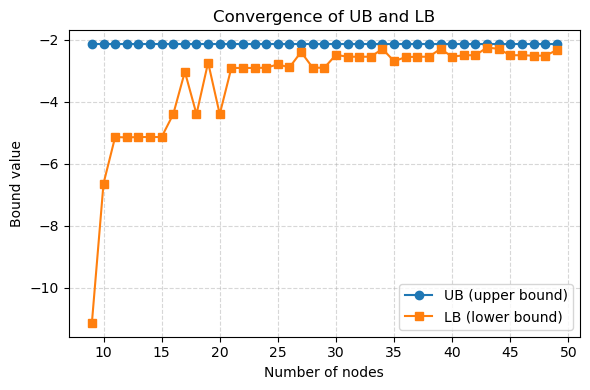

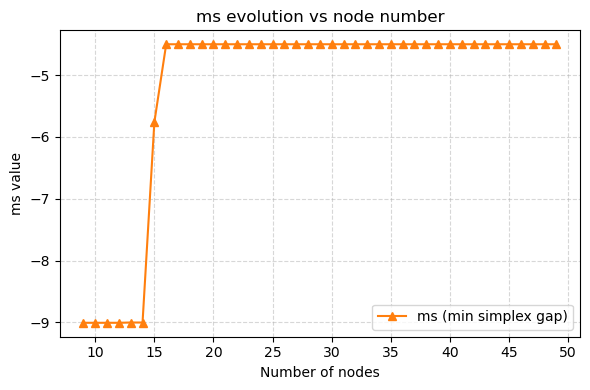

In [7]:
# ===================== Plot convergence history =====================

# 取出数据
nodes = hist["node_count"]
LB = hist["LB_hist"]
UB = hist["UB_hist"]
ms = hist["ms_hist"]

# -------- 图1: UB & LB vs node number --------
plt.figure(figsize=(6,4))
plt.plot(nodes[1:], UB[1:], marker='o', label='UB (upper bound)')
plt.plot(nodes[1:], LB[1:], marker='s', label='LB (lower bound)')
plt.xlabel("Number of nodes")
plt.ylabel("Bound value")
plt.title("Convergence of UB and LB")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# -------- 图2: ms vs node number --------
plt.figure(figsize=(6,4))
plt.plot(nodes[1:], ms[1:], marker='^', color='tab:orange', label='ms (min simplex gap)')
plt.xlabel("Number of nodes")
plt.ylabel("ms value")
plt.title("ms evolution vs node number")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [8]:
for msi in ms:
    print(msi)

-15.638806826915822
-9.005037619854605
-9.005037476330925
-9.005037366550937
-9.005037325418535
-9.00063027248549
-9.000630093055118
-5.759732122137686
-4.5000795410808685
-4.500079554784358
-4.500079556516512
-4.500079557193482
-4.500079559060763
-4.5000795590802785
-4.500079556916262
-4.500079558425178
-4.5000795591336225
-4.50007955918492
-4.500079558445728
-4.500079554674544
-4.500079559162183
-4.500079558502378
-4.5000795547120305
-4.500079558510379
-4.500079559185602
-4.5000795590886415
-4.500079561411736
-4.500079559095594
-4.500079559098747
-4.500079558446551
-4.500079558450187
-4.500079559065162
-4.50007955849364
-4.500079557248604
-4.5000795591876965
-4.500079558169741
-4.500079559041087
-4.5000795591838845
-4.500079559179964
-4.5000795590555835
-4.500079559180914
-4.500079557099468
